# Correlation

## Imports and Data Loading

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [51]:
data_path = '../../data/raw/AmesHousing.csv'

df = pd.read_csv(data_path)
df.head(3)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [52]:
# these are categorical variables although they are represented as numbers
df['MS SubClass'] = df['MS SubClass'].astype('object') 
df['Overall Qual'] = df['Overall Qual'].astype('object') 

numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

## Target Distribution

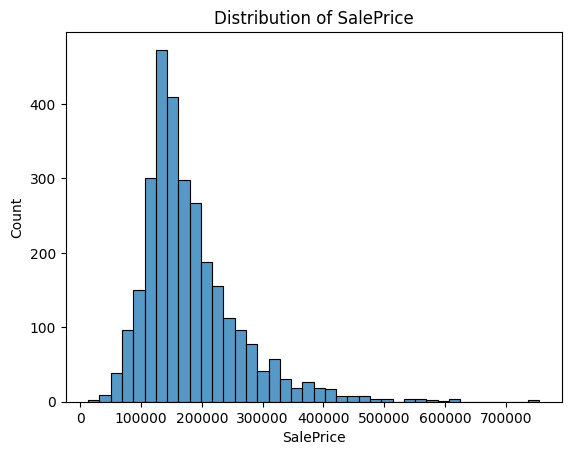

In [53]:
plt.figure()
sns.histplot(df['SalePrice'], bins=40)
plt.title("Distribution of SalePrice")
plt.show()

## Pearson Correlation with the Target Variable

In [54]:
pearson_corr = df.corr(numeric_only=True)

pearson_corr_with_target = pearson_corr['SalePrice'].sort_values(ascending=False)
pearson_corr_with_target.head(20)

SalePrice         1.000000
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Lot Frontage      0.357318
Wood Deck SF      0.327143
Open Porch SF     0.312951
Half Bath         0.285056
Bsmt Full Bath    0.276050
2nd Flr SF        0.269373
Name: SalePrice, dtype: float64

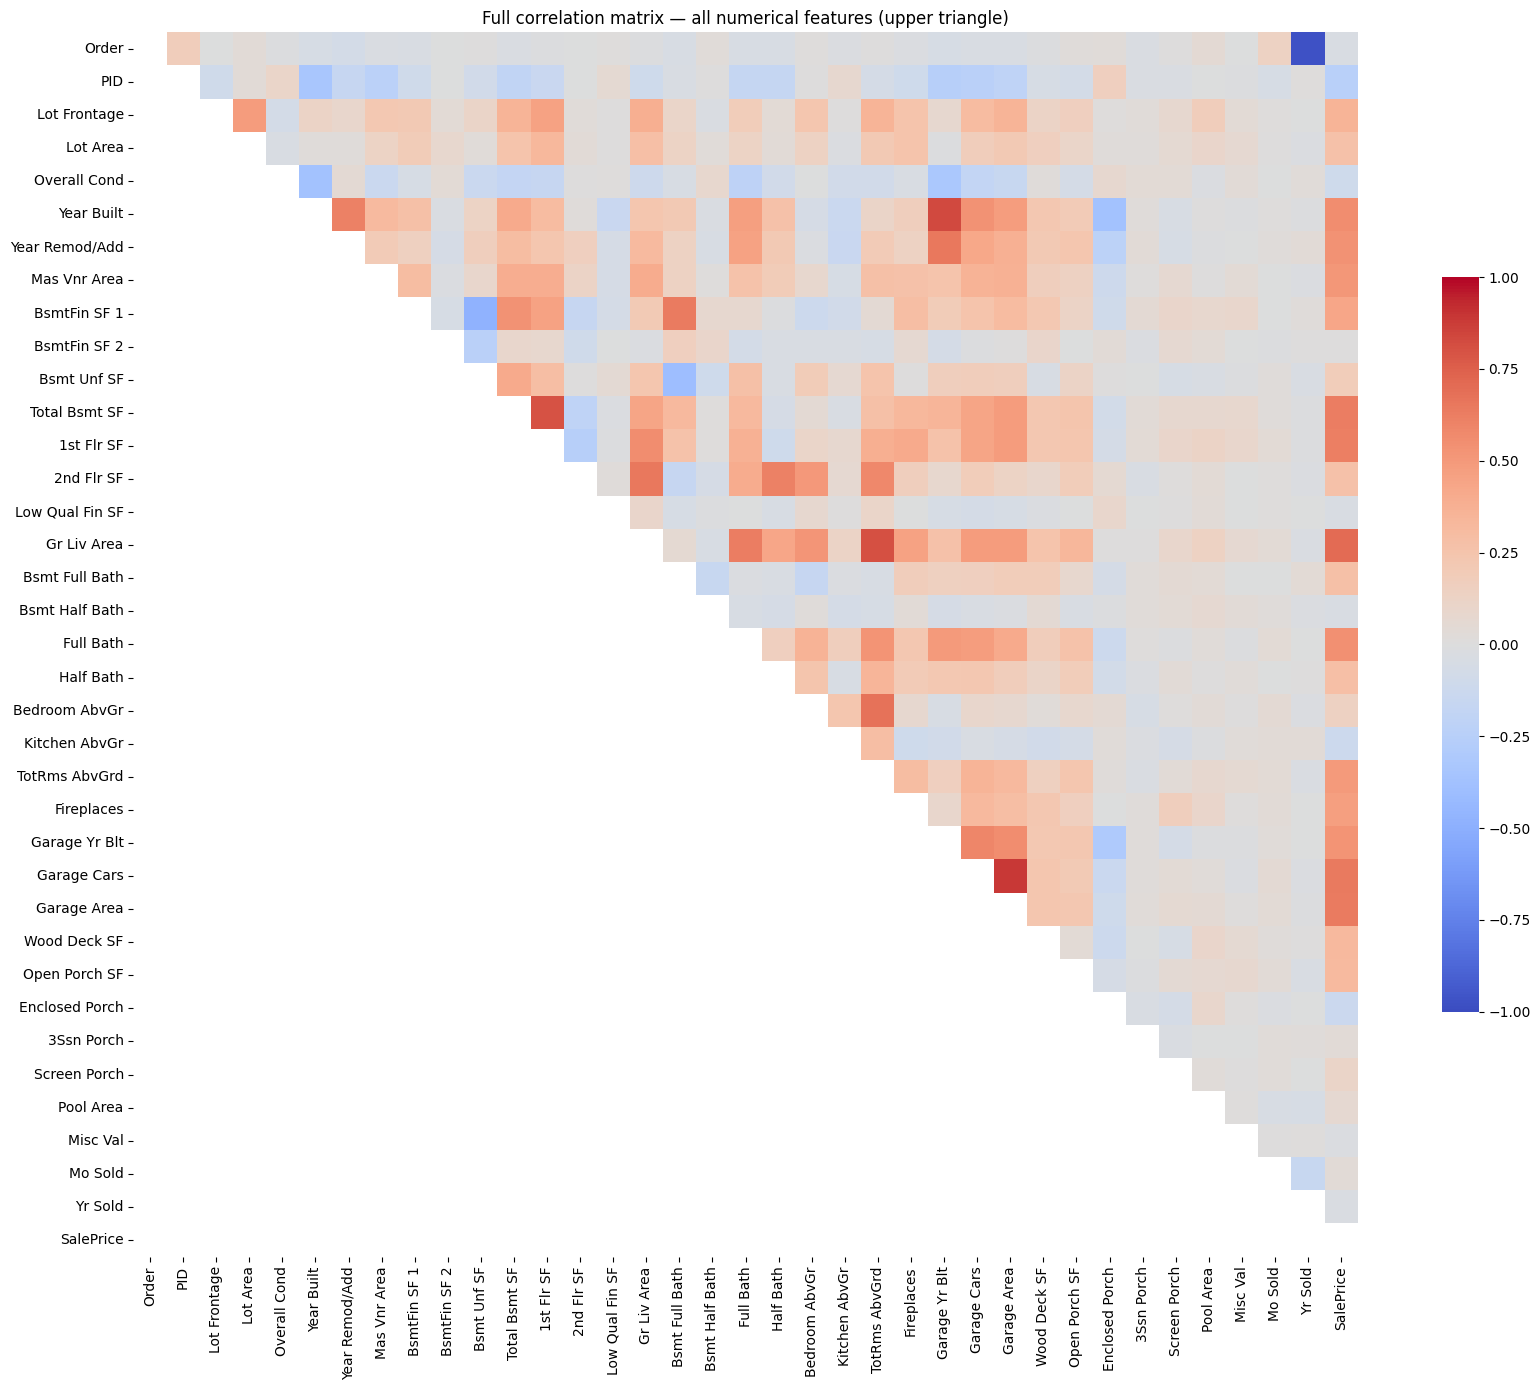

In [74]:
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)  # True = show upper tri
mask = ~mask  # seaborn mask=True means HIDE, so invert

fig, ax = plt.subplots(figsize=(18, 14))

sns.heatmap( pearson_corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0, square=True, cbar_kws={"shrink": .6}, ax=ax)

ax.set_title("Full correlation matrix — all numerical features (upper triangle)")
plt.tight_layout()
plt.show()

In [71]:
print("----- Top 10 features most correlated with SalePrice: ----- ")
top_10_features = pearson_corr_with_target.drop('SalePrice').head(10)
print(top_10_features)

----- Top 10 features most correlated with SalePrice: ----- 
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
Name: SalePrice, dtype: float64


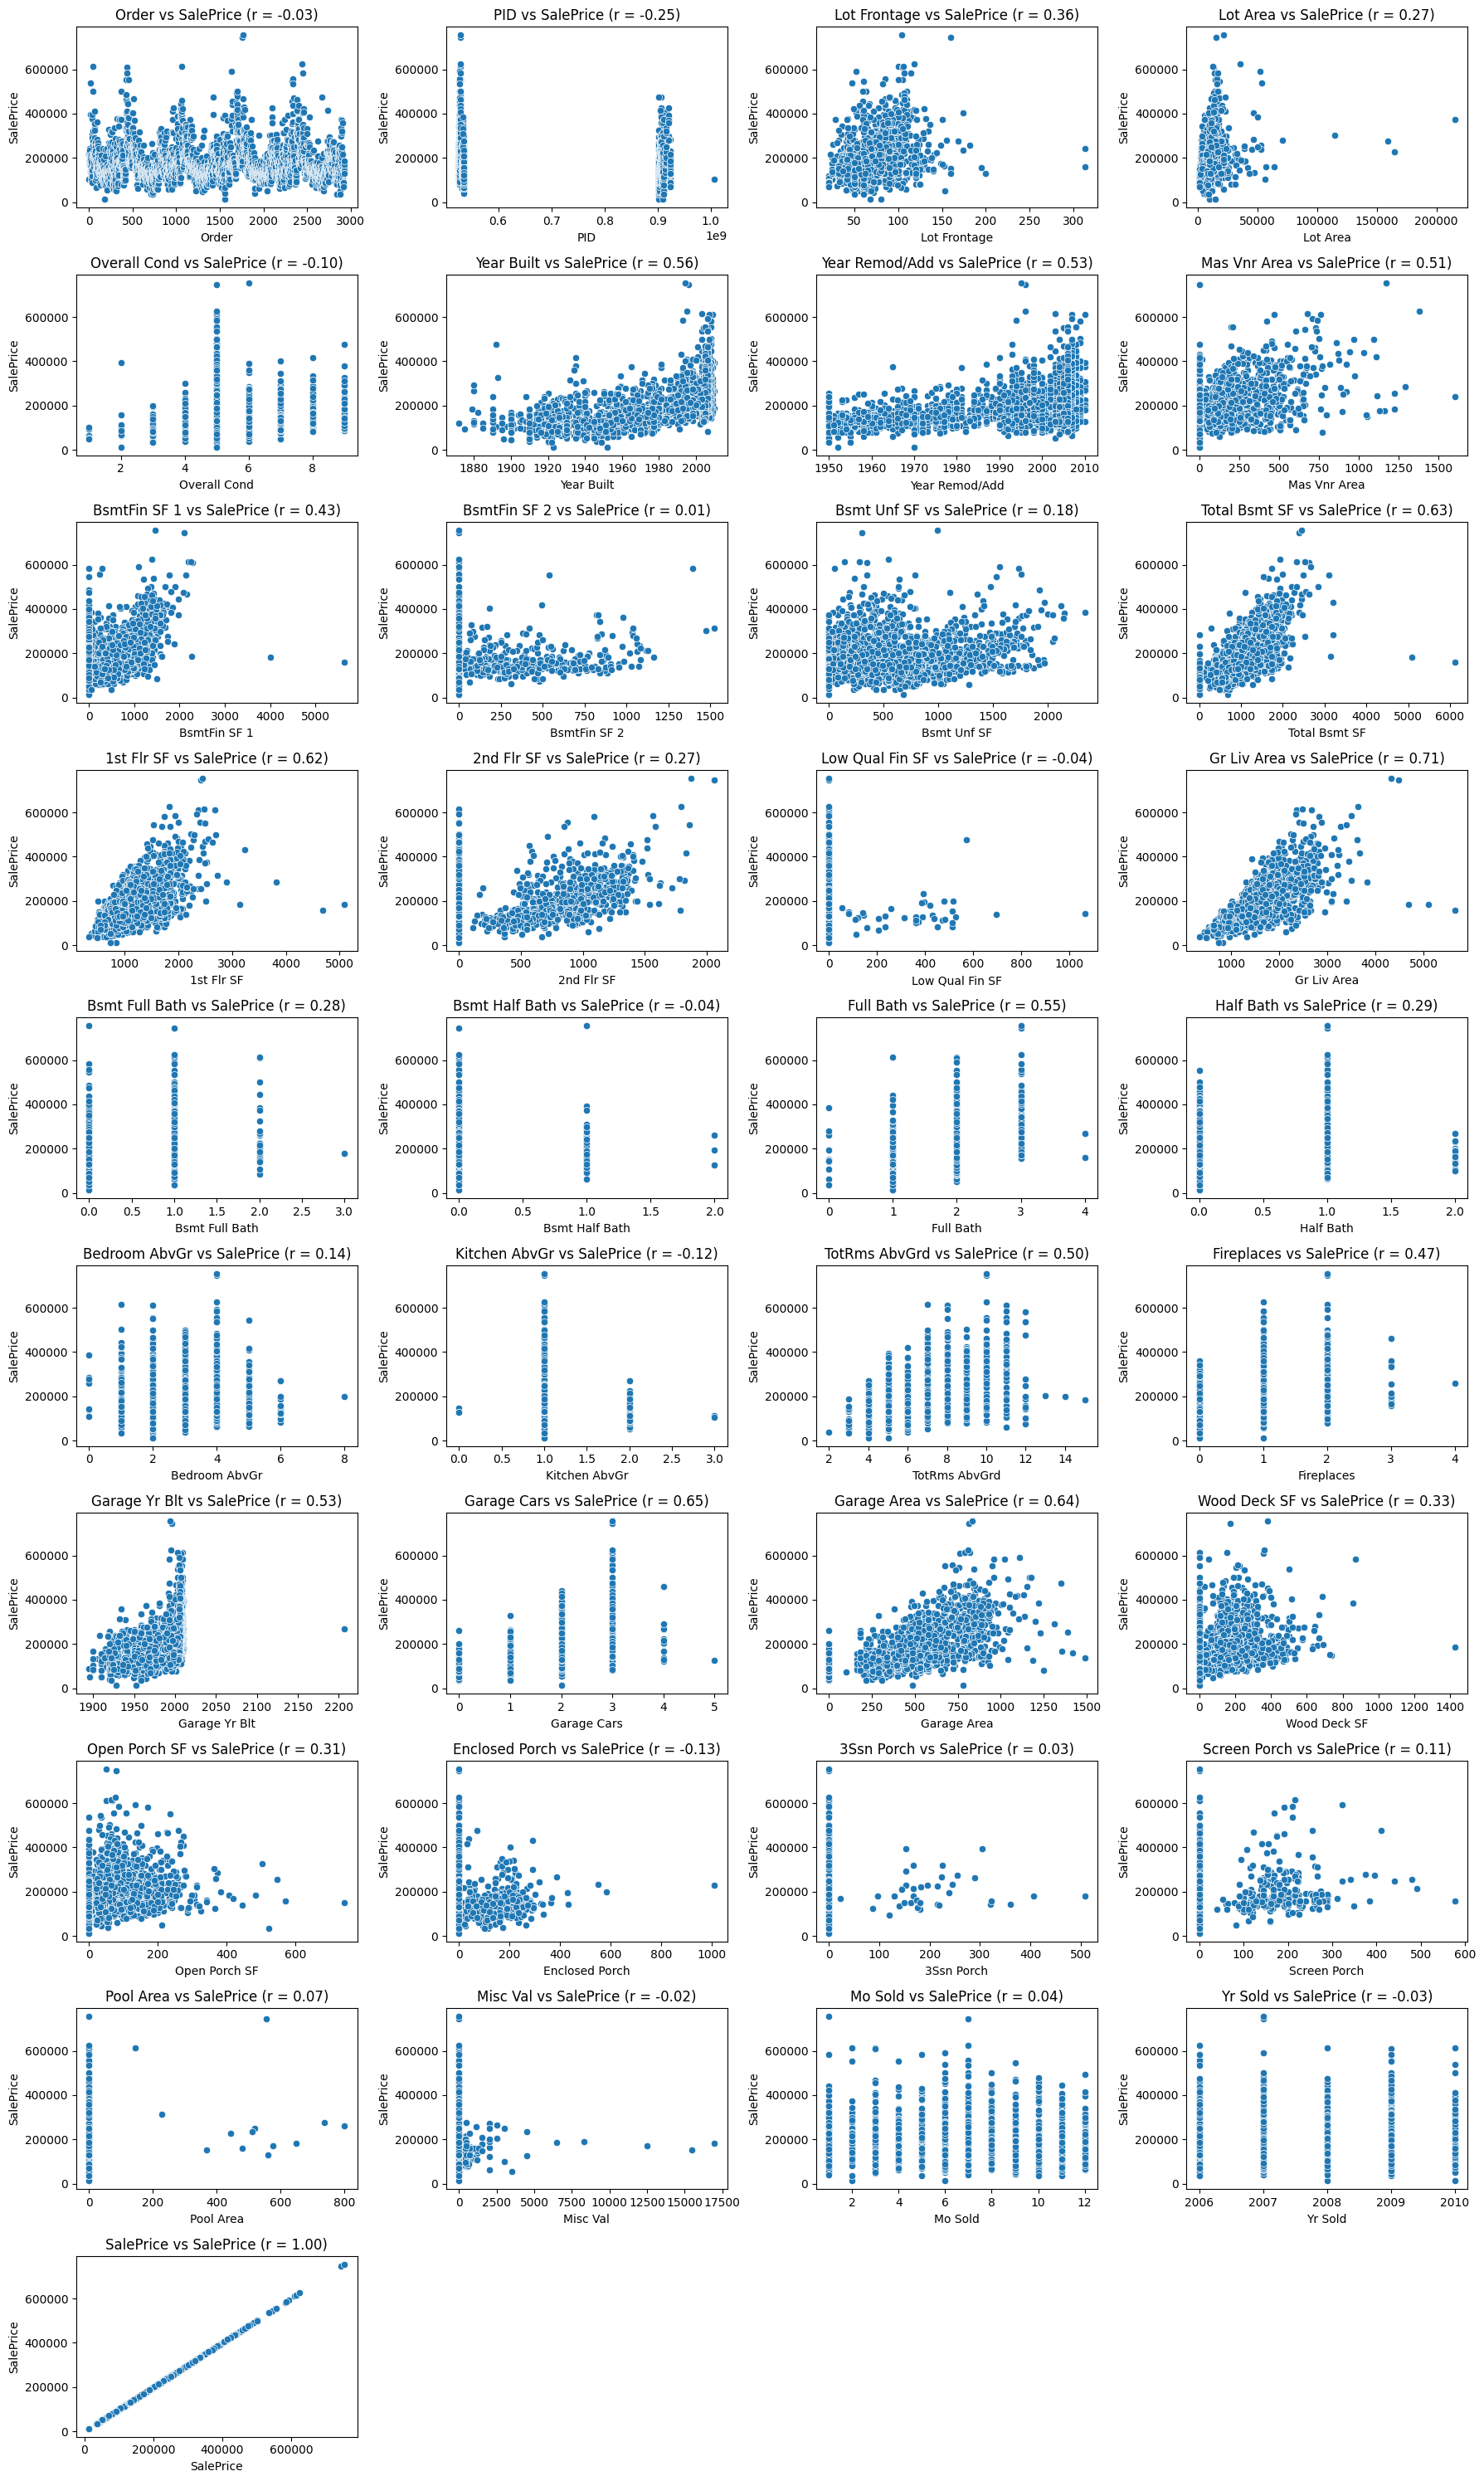

In [57]:
n_cols = 4
n_features = len(numerical_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.scatterplot(x=df[feature], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f"{feature} vs SalePrice (r = {pearson_corr_with_target[feature]:.2f})")

plt.tight_layout()

#Cleanup extra subplots
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()  


## Comparison Between Pearson and Spearman Correlation an with Target Value

In [58]:
spearman_corr = df.corr(method='spearman', numeric_only=True)

spearman_corr_with_target = spearman_corr['SalePrice'].sort_values(ascending=False)
spearman_corr_with_target.head(20)

correlation_comparison = pd.DataFrame({
    'Pearson': pearson_corr_with_target,
    'Spearman': spearman_corr_with_target
}).sort_values(by='Pearson', ascending=False)

correlation_comparison.head(20)

,Pearson,Spearman
SalePrice,1.000000,1.000000
Gr Liv Area,0.706780,0.723342
Garage Cars,0.647877,0.701813
Garage Area,0.640401,0.660676
Total Bsmt SF,0.632280,0.606184
1st Flr SF,0.621676,0.581536
Year Built,0.558426,0.680822
Full Bath,0.545604,0.634161
Year Remod/Add,0.532974,0.601454
Garage Yr Blt,0.526965,0.637674


## Correlation of Categorical Variables with Target

In [59]:
categorical_low_cardinality = [col for col in categorical_features if df[col].nunique() <= 10]

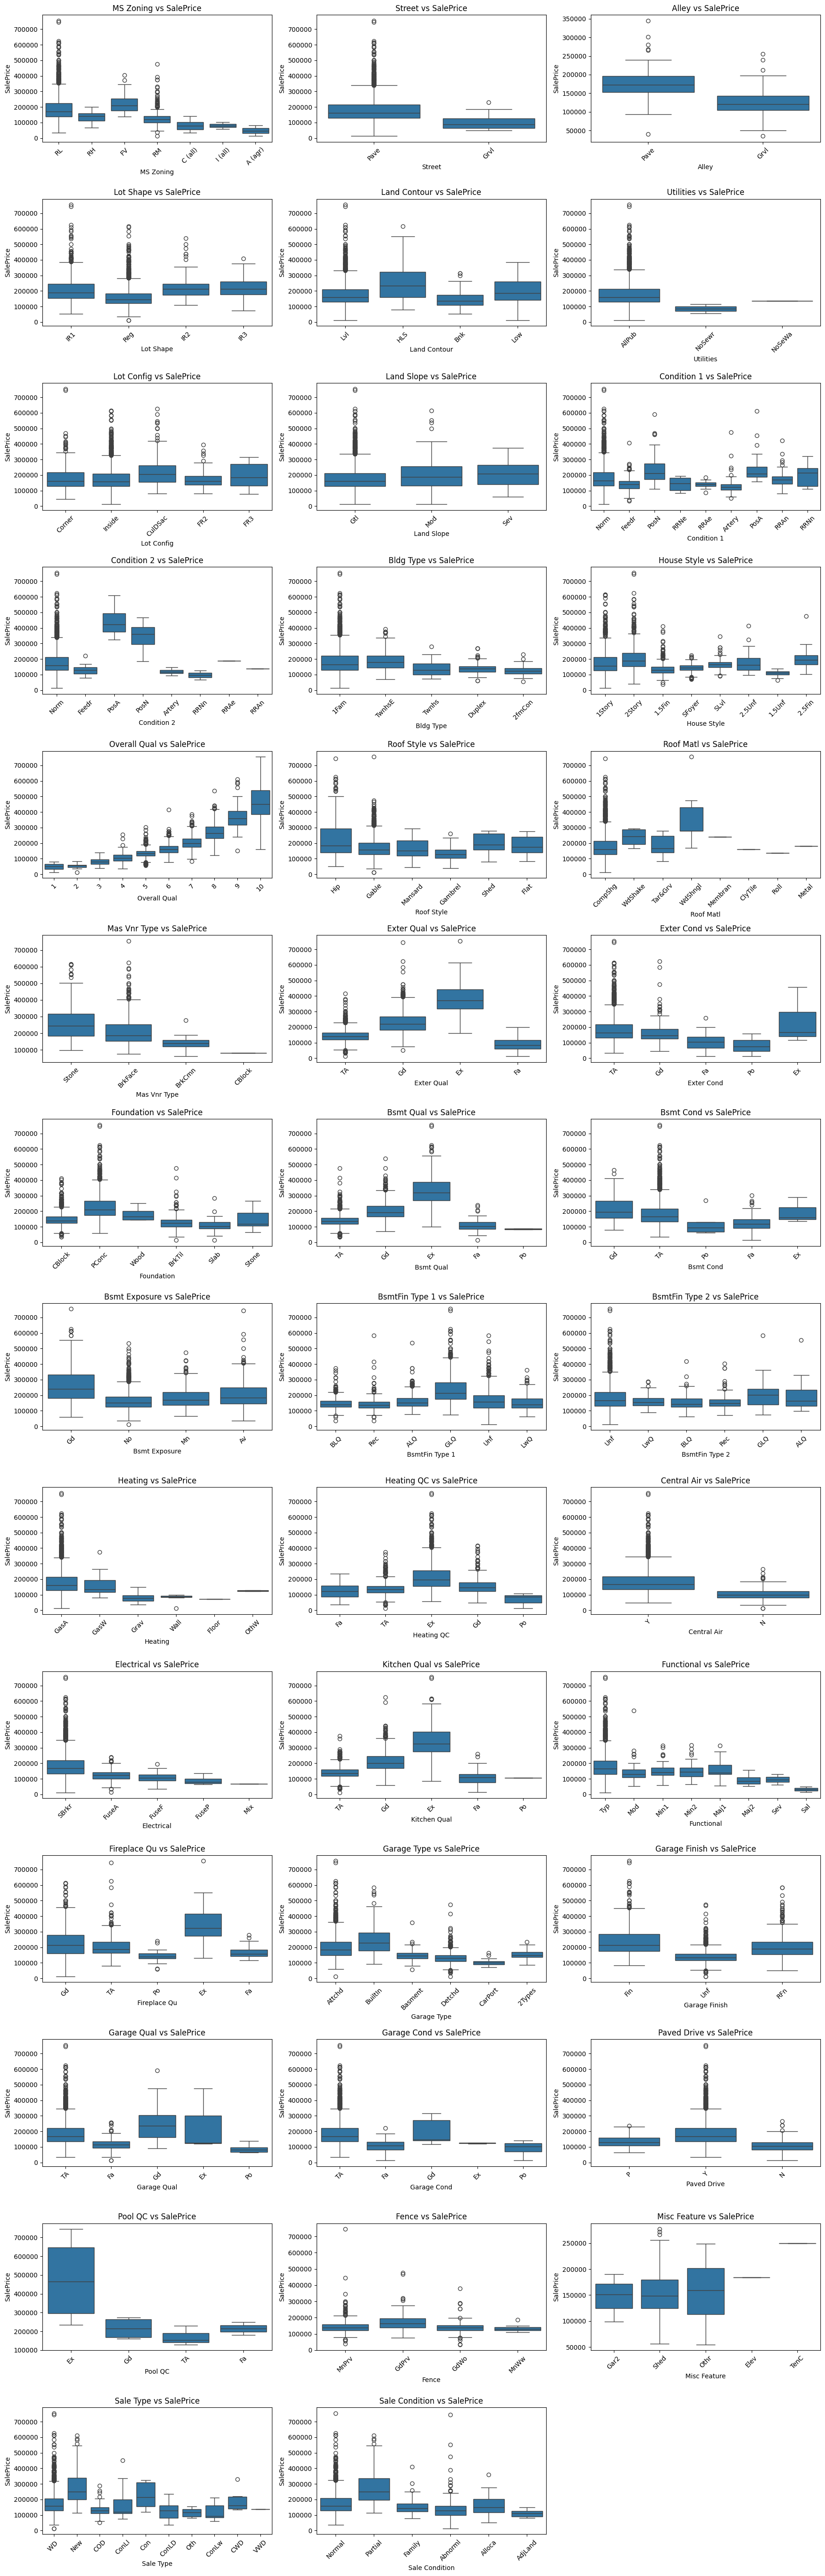

In [60]:
n_cols = 3
n_features = len(categorical_low_cardinality)
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(categorical_low_cardinality):
    sns.boxplot(x=df[feature], y=df['SalePrice'], ax=axes[i])
    axes[i].set_title(f"{feature} vs SalePrice")
    axes[i].tick_params(axis='x', rotation=45)

#Cleanup extra subplots
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()

## Multicollinearity

In [67]:
feature_corr = df[numerical_features].drop(columns=['SalePrice']).corr()

high_corr_mask = (feature_corr.abs() > 0.5) & (feature_corr != 1.0)

vif_variables = list(
    set(feature_corr.columns[high_corr_mask.any(axis=0)].tolist())
)

bsmt_cols  = [c for c in vif_variables if 'Bsmt'  in c]
grg_cols   = [c for c in vif_variables if 'Garage' in c]
X_vif = df[vif_variables].copy()
X_vif[bsmt_cols + grg_cols] = X_vif[bsmt_cols + grg_cols].fillna(0)
X_vif = X_vif.dropna() 

X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
             for i in range(X_vif.shape[1])]
})

vif_df[vif_df['variable'] != 'const'].sort_values(by='VIF', ascending=False)

,variable,VIF
5,Gr Liv Area,125.627507
10,2nd Flr SF,91.257434
3,1st Flr SF,77.242770
16,Order,24.367474
7,Yr Sold,24.315512
15,Garage Cars,6.146778
2,Garage Area,5.386969
4,TotRms AbvGrd,3.977915
17,Total Bsmt SF,3.376434
14,Year Built,2.651170
